In [1]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42

ERROR 1: PROJ: proj_create_from_database: Open of /dss/work/noge4093/miniconda3/envs/feems/share/proj failed


In [2]:
metadata = pd.read_csv("../meta_apal_20260413_2338.csv")

In [ ]:
metadata

In [3]:
metadata = metadata.rename(columns = {"affymetrix_id": "Affymetrix ID"})

In [4]:
%%bash
source ~/.bashrc
conda activate orbicella
bcftools query -l ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered_downsampled_maffiltered_ldfiltered.vcf.gz \
    > ../vcfsamps.txt        

In [5]:
vcfsamps = pd.read_csv("../vcfsamps.txt", header = None, names = ["Affymetrix ID"])

In [6]:
vcfsamps = vcfsamps.merge(metadata, how = "left", on = "Affymetrix ID")

In [7]:
samplesizes = pd.DataFrame(vcfsamps.value_counts(["lat_clean", "lon_clean"])).reset_index(drop=False)

In [8]:
vcfsamps.loc[vcfsamps["reef"] == "Alacranes", "region"] = "Mexico, Gulf Side"
vcfsamps.loc[vcfsamps["reef"] == "Veracruz", "region"] = "Mexico, Gulf Side"
vcfsamps.loc[vcfsamps["reef"] == "Serrana", "region"] = "Colombia, San Andres"
vcfsamps.loc[vcfsamps["reef"] == "Roncador", "region"] = "Colombia, San Andres"

In [9]:
vcfsamps.loc[(vcfsamps["reef"] == "Honduras - Doubke Woww (North Central)"), "lon_clean"] = -86.661018 #generic
vcfsamps.loc[(vcfsamps["reef"] == "Honduras - Doubke Woww (North Central)"), "lat_clean"] = 15.825861 #generic
vcfsamps.loc[(vcfsamps["reef"] == "Honduras - Prolifera Patch"), "lon_clean"] = -86.661018 #generic
vcfsamps.loc[(vcfsamps["reef"] == "Honduras - Prolifera Patch"), "lat_clean"] = 15.825861 #generic
vcfsamps.loc[(vcfsamps["reef"] == "Honduras - Cocalita"), "lon_clean"] = -87.6191195 #cocalito
vcfsamps.loc[(vcfsamps["reef"] == "Honduras - Cocalita"), "lat_clean"] = 15.9245029 #cocalito
vcfsamps.loc[(vcfsamps["reef"] == "Honduras - Palma Vista"), "lon_clean"] = -86.661018 #cocalito
vcfsamps.loc[(vcfsamps["reef"] == "Honduras - Palma Vista"), "lat_clean"] = 15.825861 #cocalito

In [10]:
vcfsamps.loc[(vcfsamps["reef"].isin(["MML International Gene Bank", "The Reef Institute"])) & (vcfsamps["region"] == "Florida"), "lat_clean"] = 24.6629189 #generic point in middle keys
vcfsamps.loc[(vcfsamps["reef"].isin(["MML International Gene Bank", "The Reef Institute"])) & (vcfsamps["region"] == "Florida"), "lon_clean"] = -81.0075715 #generic point in middle keys

In [11]:
samplesizes = pd.DataFrame(vcfsamps.value_counts(["lat_clean", "lon_clean"])).reset_index(drop=False)

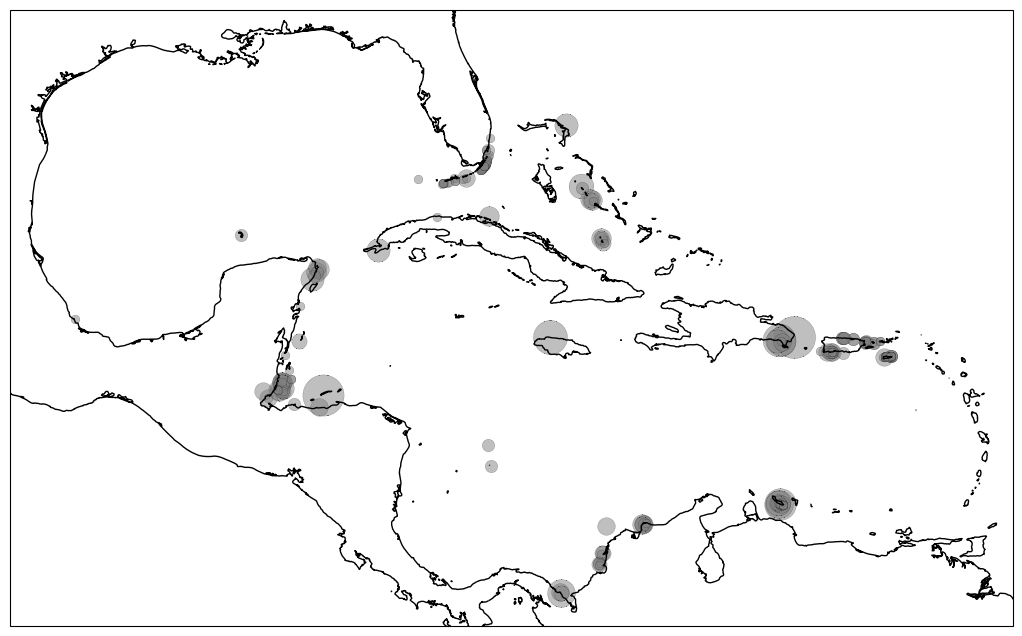

In [12]:
plt.figure(figsize=(16,8))

ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([-98.6, -59.89, 7.42, 29.9])
ax.coastlines(resolution='10m')

for i in range(len(samplesizes)):
    plt.scatter([samplesizes["lon_clean"][i]], 
             [samplesizes["lat_clean"][i]], 
             s = samplesizes["count"][i]*40,
         color='grey', marker='o', linewidths=0.2, 
                alpha = 0.5, edgecolor = "black",
         transform=ccrs.PlateCarree(),
         )

plt.savefig("../figures/structure_map.pdf", dpi = 300)

In [14]:
# base
import numpy as np
# import pkg_resources -> deprecated
from importlib import resources
from sklearn.impute import SimpleImputer
from pandas_plink import read_plink
import statsmodels.api as sm

# viz
import matplotlib.pyplot as plt
from matplotlib import gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# feems
from feems.utils import prepare_graph_inputs, cov_to_dist
from feems.objective import comp_mats
from feems.viz import draw_FEEMSmix_surface, plot_FEEMSmix_summary
from feems import SpatialGraph, Objective, Viz
from feems.cross_validation import run_cv, run_cv_joint

# change matplotlib fonts
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.sans-serif"] = "Arial"

## Data

In [15]:
%%bash
source ~/.bashrc
conda activate orbicella
plink2 --vcf ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered_downsampled_maffiltered_ldfiltered.vcf.gz \
    --allow-extra-chr --make-bed \
    --out ../filtered_calls/feems_input

PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to ../filtered_calls/feems_input.log.
Options in effect:
  --allow-extra-chr
  --make-bed
  --out ../filtered_calls/feems_input
  --vcf ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered_downsampled_maffiltered_ldfiltered.vcf.gz

Start time: Tue Apr 28 23:24:32 2026
771373 MiB RAM detected, ~339116 available; reserving 339052 MiB for main
workspace.
Using up to 8 compute threads.
--vcf: 3215 variants scanned.
--vcf: ../filtered_calls/feems_input-temporary.pgen +
../filtered_calls/feems_input-temporary.pvar.zst +
../filtered_calls/feems_input-temporary.psam written.
554 samples (0 females, 0 males, 554 ambiguous; 554 founders) loaded from
../filtered_calls/feems_input-temporary.psam.
Note: 14 nonstandard chromosome codes present.
3215 variants loaded from ../filtered_calls/feems_input-temporar

In [16]:
# read the genotype data and mean impute missing data
(bim, fam, G) = read_plink("/fs/dss/work/noge4093/apal_popgen/filtered_calls/feems_input")
imp = SimpleImputer(missing_values=np.nan, strategy="mean")
genotypes = imp.fit_transform((np.array(G)).T)

print("n_samples={}, n_snps={}".format(genotypes.shape[0], genotypes.shape[1]))

Mapping files: 100%|██████████| 3/3 [00:00<00:00, 323.05it/s]
/dss/work/noge4093/miniconda3/envs/feems/lib/python3.12/site-packages/pandera/_pandas_deprecated.py:146: FutureWarning: Importing pandas-specific classes and functions from the
top-level pandera module will be **removed in a future version of pandera**.
If you're using pandera to validate pandas objects, we highly recommend updating
your import:

```
# old import
import pandera as pa

# new import
import pandera.pandas as pa
```

If you're using pandera to validate objects from other compatible libraries
like pyspark or polars, see the supported libraries section of the documentation
for more information on how to import pandera:

https://pandera.readthedocs.io/en/stable/supported_libraries.html

To disable this warning, set the environment variable:

```
export DISABLE_PANDERA_IMPORT_WARNING=True
```

  warnings.warn(_future_warning, FutureWarning)


n_samples=554, n_snps=3215


In [17]:
vcfsamps[["lon_clean", "lat_clean"]].to_csv("../feems_input.coord", 
                                                        sep = "\t", header = None, index = False)

In [18]:
coord = np.loadtxt("../feems_input.coord")  # sample coordinates

In [19]:
outer = (("-76.7108207 7.9215251, -76.6943412 8.0901535, -76.7382865 8.4380648, -76.9085746 8.5412913, -76.8536429 8.6173351, -76.6284232 8.6281972, -76.6009574 8.7096533, -76.3482718 8.8942213, -76.0955863 9.2251236, -76.0681205 9.3118668, -75.9143119 9.4311034, -75.6561332 9.3931689, -75.5462699 9.5773829, -75.5737357 9.7019418, -75.6890922 9.7181852, -75.5188041 10.086155, -75.5133109 10.2483621, -75.4748588 10.567126, -75.3595023 10.675107, -75.2276664 10.6913009, -74.9914603 10.9610703, -74.9090629 11.0203868, -74.6838431 11.0365619, -74.4970756 10.971856, -74.4641166 10.7452741, -74.3322806 10.7560676, -74.1619925 11.0796913, -74.178472 11.2736945, -73.9587455 11.3329473, -73.8049369 11.2359819, -73.2336478 11.2683073, -72.7777152 11.6559265, -72.3374748 11.8218723, -72.2028923 11.9320713, -72.1204948 12.1093708, -72.1452141 12.2140834, -71.9831657 12.2328736, -71.9859123 12.1523348, -71.9062614 12.1469647, -71.84309 12.2597144, -71.909008 12.2865525, -71.8293571 12.3563188, -71.7963981 12.2919198, -71.724987 12.3616846, -71.6892814 12.3697332, -71.6700554 12.4475234, -71.5107536 12.4207019, -71.2855339 12.3294878, -71.2333488 12.308021, -71.2196159 12.2543465, -71.0960197 12.0341671, -71.2937736 11.9213222, -71.3651848 11.7896105, -71.4475822 11.7196969, -71.9556999 11.6094127, -71.9694328 11.4102529, -71.8650627 11.1840104, -71.7085075 11.0303878, -71.3612695 10.9602564, -71.2115807 10.9912643, -70.844912 11.1920624, -70.6485314 11.2270868, -70.5290551 11.2297808, -70.4864831 11.2863491, -70.4384179 11.2782686, -70.283236 11.3469457, -70.2131982 11.3388669, -70.1349206 11.4492574, -70.0909753 11.4263751, -70.0456567 11.4425275, -70.0374169 11.5017451, -69.9083276 11.4977079, -69.8533959 11.425029, -69.7160668 11.4815587, -69.806704 11.6833575, -70.2269311 11.599965, -70.2379174 11.801678, -70.2846093 11.8876972, -70.1884789 12.0999404, -70.0044579 12.1912339, -69.9110741 12.1831798, -69.8204369 11.976376, -69.7682519 11.7156318, -69.6666283 11.5084736, -69.5952172 11.4465655, -69.5183129 11.4950165, -69.4111962 11.4869419, -69.2656274 11.5326948, -69.0294213 11.4331054, -68.8308196 11.4340256, -68.6962371 11.3397874, -68.5341888 11.2535996, -68.3776336 11.1646914, -68.2787566 10.9112891, -68.2128387 10.8654378, -68.3281951 10.8303703, -68.3227019 10.7251431, -68.1688933 10.4848728, -67.9326873 10.4524625, -66.6747527 10.6144803, -66.2462859 10.6198794, -66.0430389 10.5550836, -66.1034637 10.5010768, -65.9331756 10.3281915, -65.3838592 10.1227669, -64.9608855 10.0632772, -64.6917205 10.0957275, -64.6312957 10.2254958, -64.3950896 10.2957649, -64.3621307 10.3714218, -64.1973357 10.4146461, -64.2632537 10.6360762, -63.7523894 10.6630689, -63.4832244 10.6306774, -63.0712371 10.7170472, -62.6812225 10.7440328, -61.8572478 10.7062523, -61.9451385 10.6252784, -62.2692351 10.6522721, -62.3021941 10.5388826, -62.8405242 10.5604838, -62.6482635 10.3444036, -62.631784 10.1930587, -62.532907 10.2200898, -62.4285369 10.0308236, -62.3241668 9.9496755, -62.2417693 10.0308236, -61.9671111 9.9388543, -61.8462615 9.8089712, -61.626535 9.8089712, -61.6649871 9.900977, -61.527658 9.8630954, -61.3958221 9.8089712, -61.225534 9.6032191, -60.8739715 9.4515321, -60.7860808 9.2997782, -60.8739715 9.0611751, -60.6102996 8.6921145, -60.3466277 8.6486714, -59.9071746 8.5834974, -59.050241 7.952917, -58.4569793 7.3431585, -52.4364715 11.3963341, -55.6884246 18.2943274, -62.0165496 22.0472344, -66.8065887 22.5757506, -69.4872527 23.5461409, -73.6181121 26.6889669, -75.4638152 28.9045895, -76.6503387 30.7345452, -77.265573 31.861024, -81.4788299 30.743988, -81.4513641 30.4745069, -81.4293914 30.4366251, -81.2591033 29.7140854, -80.8635955 28.8757323, -80.8416228 28.6976029, -80.1879363 27.1249308, -80.0731546 26.9218221, -80.0401956 26.6373905, -80.1445658 25.8985119, -80.3313333 25.5620143, -80.3478128 25.3487392, -80.4741556 25.2394759, -80.622471 25.2444446, -80.6444437 25.1947489, -80.9740335 25.1649218, -81.0784037 25.1599499, -81.1608011 25.2444446, -81.1168558 25.4331024, -81.3640482 25.8688593, -81.7211038 25.9726108, -81.8694193 26.4604892, -81.9902689 26.4850752, -82.0781595 26.4211408, -82.160557 26.4555714, -82.3253519 26.9071276, -82.8284675 27.8530197, -82.7625495 28.2311844, -82.6526862 28.5404766, -82.7405769 29.0219308, -82.8614265 29.1659324, -83.081153 29.1659324, -83.5975105 29.8352631, -84.0369636 30.1112558, -84.3555671 30.0732334, -84.3665534 29.94956, -84.9598151 29.7112939, -85.289405 29.6826638, -85.5311042 30.1397629, -86.1133796 30.3580439, -86.7725593 30.3770019, -87.1790534 30.3770019, -87.39878 30.2726873, -87.9151374 30.2442187, -87.9810554 30.6420275, -88.1458503 30.3390822, -89.2554694 30.3296, -89.7498542 30.0447071, -89.376319 29.7112939, -89.3653327 29.1851174, -90.9253913 29.1563386, -93.2105476 29.7494546, -94.2212897 29.6540256, -95.3199226 29.0027153, -97.2535163 27.9015765, -97.4292976 26.6910032, -97.0557624 25.685448, -97.8028327 25.3483489, -97.8248054 22.7400684, -97.912696 22.6285673, -97.8852302 22.3494192, -97.7094489 21.9271005, -97.3331672 21.5520696, -97.4375373 21.2707977, -97.3633796 21.0582084, -97.2315437 20.8170775, -97.1985847 20.6835196, -97.0969611 20.5395566, -96.59159 20.0191398, -96.4542609 19.8125543, -96.355384 19.4244842, -96.2674934 19.2534381, -96.1246711 19.1133585, -95.9653693 19.0147126, -95.9488898 18.8588369, -95.8609992 18.7184248, -95.18534 18.6820026, -95.015052 18.5154015, -94.8282844 18.5154015, -94.6525031 18.2756282, -94.5975715 18.1451772, -94.3723518 18.1608365, -94.2185432 18.1556169, -93.4330207 18.4007689, -92.839759 18.4007689, -92.6694709 18.572689, -92.3234016 18.6507773, -92.0102912 18.6663906, -91.8509895 18.5883095, -90.8732063 19.1756308, -90.6754523 19.3571238, -90.6754523 19.6729571, -90.4227668 19.9158808, -90.4722053 20.4829625, -90.3238898 20.9915515, -90.0712043 21.1350831, -89.225257 21.3450037, -88.7858039 21.3910437, -88.58805 21.5086357, -88.3793098 21.5546242, -88.2474738 21.5597331, -88.1431037 21.600598, -87.2916633 21.4166153, -87.1103889 21.4472952, -87.0664436 21.5597331, -86.9620734 21.4779687, -86.8686897 21.3143023, -86.8247443 21.1555763, -86.8686897 20.8940763, -87.280677 20.4778166, -87.4729377 20.1378038, -87.5333625 20.1274888, -87.4454719 19.8848899, -87.7585822 19.6626117, -87.7640754 19.5642973, -87.6597053 19.4866383, -87.4619514 19.5798246, -87.4619514 19.4918167, -87.6871711 19.3623064, -87.6871711 19.1600649, -87.6267463 19.1704423, -87.5058967 19.2897356, -87.7530891 18.6195463, -87.8409797 18.1451772, -87.9123908 18.4320399, -88.0332404 18.5154015, -87.9892951 18.7444359, -88.0607063 18.9056149, -88.1705695 18.7496376, -88.3243781 18.4580947, -88.4562141 18.3486379, -88.2309943 18.3173518, -88.0991584 18.3486379, -88.0991584 18.1190753, -88.2255012 17.9048933, -88.3078986 17.6014625, -88.2110512 17.5160901, -88.3099281 17.3588684, -88.3264076 17.1070335, -88.2275306 17.01776, -88.2989418 16.8601146, -88.3044349 16.7602044, -88.4252846 16.5444303, -88.4692299 16.4074725, -88.5845863 16.2440506, -88.6614906 16.312599, -88.7603676 16.2493244, -88.7603676 16.1596506, -88.9636146 15.9801811, -88.9306556 15.8745355, -88.7823402 15.8586839, -88.7823402 15.7952649, -88.6505043 15.7476876, -88.6010658 15.657789, -88.507682 15.842831, -88.5900795 15.9326475, -88.106681 15.6419204, -88.0462562 15.789979, -87.9089271 15.789979, -87.9199135 15.8481154, -87.7056801 15.9009521, -87.4639808 15.7529745, -87.3705971 15.8216919, -86.832267 15.7212509, -86.700431 15.8058361, -86.6125404 15.7741208, -86.4916908 15.8058361, -86.3763344 15.7529745, -86.1181556 15.8851026, -85.9643471 15.8903859, -85.8819496 15.9960232, -85.6841957 15.9273653, -85.4809486 15.8269768, -85.393058 15.8586839, -85.1733314 15.8798191, -85.0469887 15.9696191, -84.8876869 15.9168004, -84.6679603 15.842831, -84.6514808 15.7582613, -84.3987953 15.8269768, -84.3109047 15.8005505, -83.8659584 15.4302224, -83.3715736 15.228909, -83.1518471 14.9796498, -83.2452308 14.9478084, -83.316642 14.6929085, -83.1902992 14.3738655, -83.3221351 14.1183023, -83.4594642 13.9477672, -83.5693275 13.5155394, -83.5913002 13.2643791, -83.519889 12.8791207, -83.552848 12.5951477, -83.4814369 12.3752541, -83.651725 12.3484251, -83.7066566 12.0638694, -83.7121498 11.832781, -83.6572181 11.5961161, -83.8714515 11.4023318, -83.8824379 11.1868608, -83.6682045 10.8741437, -83.3798134 10.3152959, -83.0117714 9.9042986, -82.7700721 9.6444544, -82.6107704 9.6227916, -82.396537 9.3898294, -82.363578 9.3085265, -82.3361122 9.2163603, -82.2372352 9.1838253, -82.2701942 9.1241701, -82.2427284 8.9831272, -82.0779335 8.9288653, -81.7922889 8.9288653, -81.7428505 8.9831272, -81.8911659 9.1512873, -81.7153846 9.0265309, -81.5450966 8.7986038, -81.2869179 8.7768891, -81.0946571 8.7823179, -80.8145057 8.8637403, -80.721122 8.9885529, -80.4794227 9.1078987, -80.1553261 9.1512873, -79.9630653 9.3464702, -79.7762977 9.4386021, -79.6279823 9.5686285, -79.0347206 9.5361266, -79.0676796 9.4548581, -78.6282264 9.4060877, -78.5073768 9.411507, -78.0404579 9.2163603, -77.7273475 8.950571, -77.5295936 8.6900175, -77.3593055 8.6574355, -77.2769081 8.4890502, -77.1176063 8.3858098, -77.0571815 8.2553616, -76.9583046 8.2499253, -76.9583046 8.1792469, -76.9747841 8.1085559, -76.9198524 8.0976792, -76.8539345 8.1357462, -76.8704139 8.0596087, -76.9473182 7.9997763, -76.9363319 7.9399351, -76.8923866 7.9018499, -76.7108207 7.9215251"))

In [20]:
outer = [i.split(" ") for i in outer.split(", ")]

In [21]:
outer = np.array(outer).astype(float)

In [22]:
!cp /fs/dss/groups/agmarinecons/apal_reference_panel/apal_reference_panel/iho_res5* ..

In [23]:
#grid_path = "{}/grid_100.shp".format(data_path)
grid_path = "../iho_res8_2.shp"
# graph input files
outer, edges, grid, _ = prepare_graph_inputs(coord=coord, 
                                             ggrid=grid_path,
                                             translated=True, 
                                             buffer=0,
                                             outer=outer)

## Following the FEEMS tutorials....setup the `SpatialGraph` object:

In [24]:
%%time
sp_graph = SpatialGraph(genotypes, coord, grid, edges, scale_snps=True)

Initializing graph...
Computing graph attributes...
Assigning samples to nodes...done.
CPU times: user 45min 7s, sys: 2min 16s, total: 47min 24s
Wall time: 47min 35s


In [25]:
projection = ccrs.PlateCarree(central_longitude=-77.32)#, central_latitude=-16.6076543)

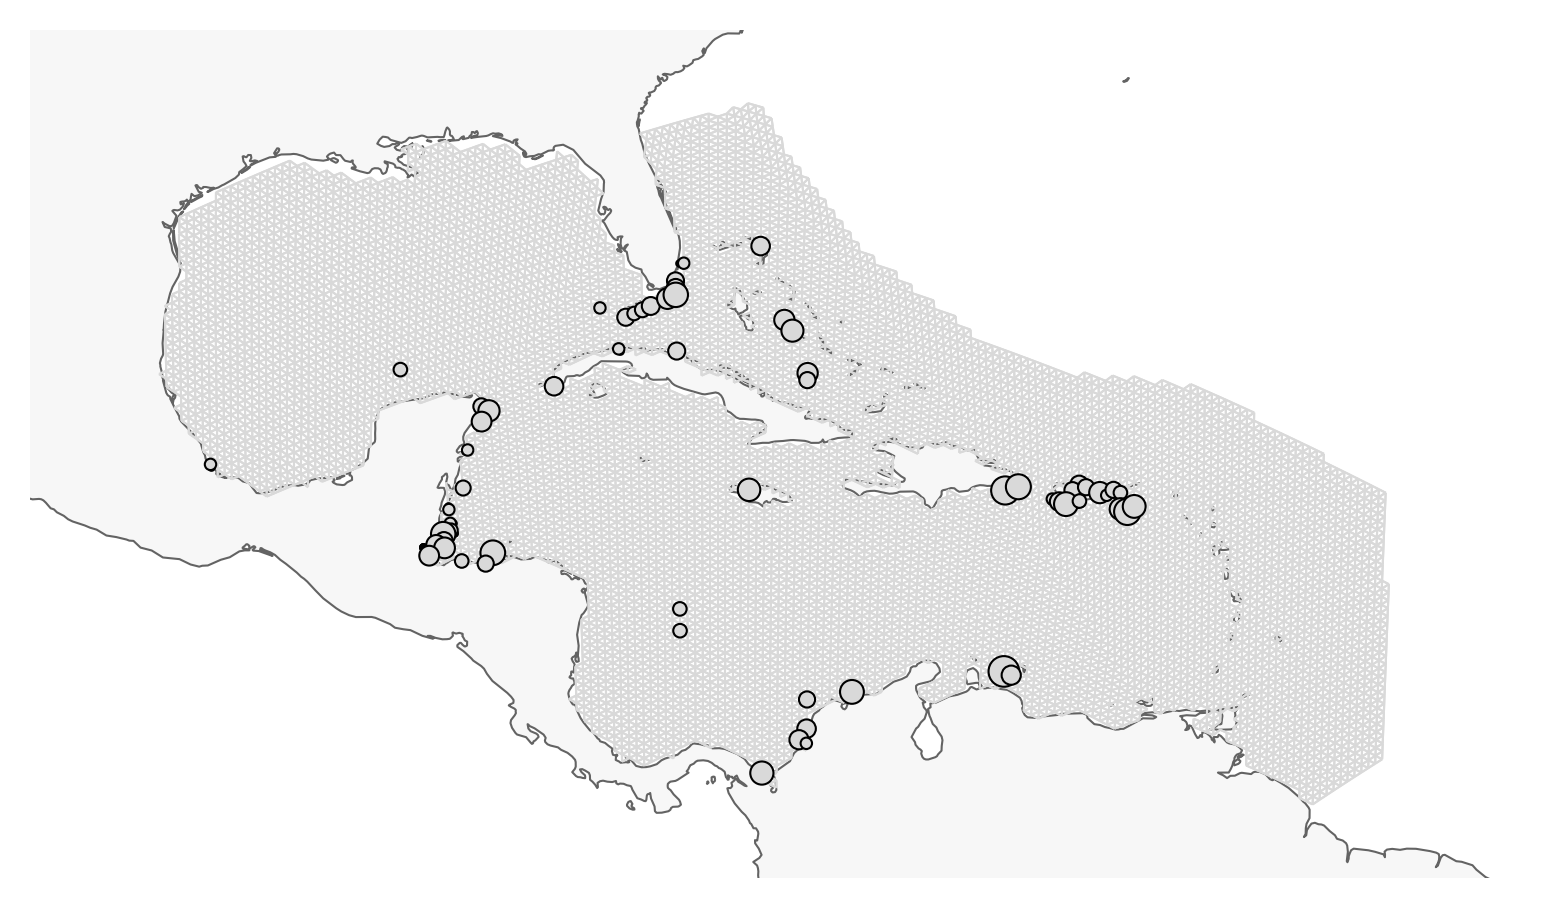

In [26]:
fig = plt.figure(dpi=300)
ax = fig.add_subplot(1, 1, 1, projection=projection)  
v = Viz(ax, sp_graph, projection=projection, edge_width=.5, 
        edge_alpha=1, edge_zorder=100, sample_pt_size=10, 
        obs_node_size=7.5, sample_pt_color="black", 
        cbar_font_size=10)
v.draw_map()
v.draw_samples()
v.draw_edges(use_weights=False)
v.draw_obs_nodes(use_ids=False)

## Fit `feems`

In [27]:
%%time
sp_graph.fit(lamb = 2.0, lamb_q = 10.0, optimize_q = 'n-dim')

CPU times: user 48min 29s, sys: 2min 26s, total: 50min 55s
Wall time: 7min 16s


In [28]:
%%time
lamb_grid = np.geomspace(1e-3, 1e2, 10, endpoint=True)[::-1]
lamb_q_grid = np.geomspace(1e-2, 1e2, 5, endpoint=True)[::-1]

cv_err = run_cv_joint(sp_graph, lamb_grid, lamb_q_grid, n_folds=5, factr=1e10)

mean_cv_err = np.mean(cv_err, axis=0)


 fold:  0
iteration lambda=10/10 lambda_q=3/5

/dss/work/noge4093/miniconda3/envs/feems/lib/python3.12/site-packages/feems/spatial_graph.py:904: RuntimeWarning: overflow encountered in power
  self.q_prox = 10**interpolate_q(np.log10(1/self.q), Rmatdo, Rmatoo)


iteration lambda=10/10 lambda_q=5/5
 fold:  1
iteration lambda=9/10 lambda_q=1/5

/dss/work/noge4093/miniconda3/envs/feems/lib/python3.12/site-packages/feems/objective.py:510: RuntimeWarning: overflow encountered in exp
  return nugget + sill * (1 - np.exp(-h / rangep))


iteration lambda=10/10 lambda_q=5/5
 fold:  2
iteration lambda=10/10 lambda_q=5/5
 fold:  3
iteration lambda=10/10 lambda_q=5/5
 fold:  4
iteration lambda=10/10 lambda_q=5/5CPU times: user 7h 51min 16s, sys: 1h 2min 38s, total: 8h 53min 54s
Wall time: 1h 26min


findfont: Font family 'Arial' not found.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Ari

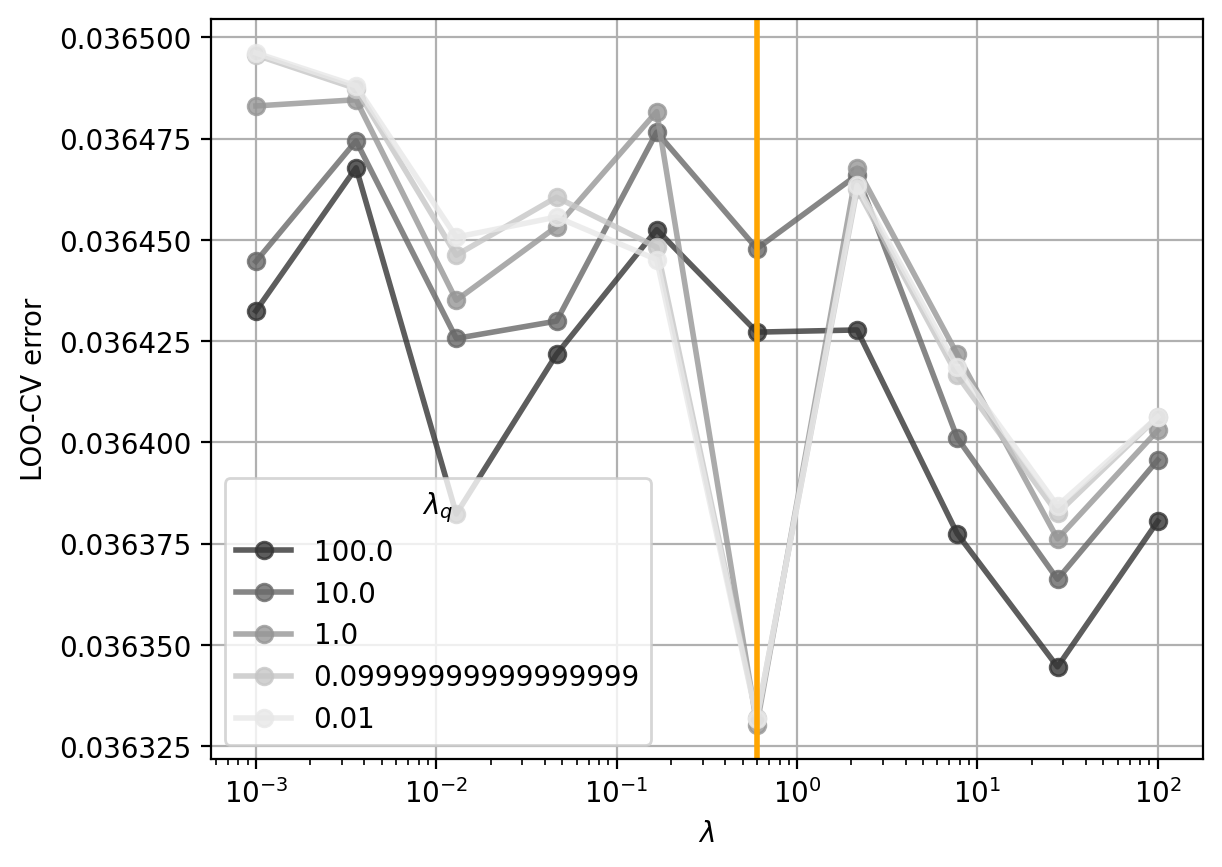

In [29]:
lamb_q_cv = lamb_q_grid[np.where(mean_cv_err == np.min(mean_cv_err))[0][0]]
lamb_cv = lamb_grid[np.where(mean_cv_err == np.min(mean_cv_err))[1][0]]

plt.figure(dpi = 200)
plt.gca().set_prop_cycle(color=[plt.get_cmap('Greys_r').resampled(len(lamb_q_grid)+2)(i) for i in range(1,len(lamb_q_grid)+1)])
lineObj = plt.plot(lamb_grid, mean_cv_err.T, '-o', linewidth = 2, alpha = 0.8)
plt.legend(lineObj, lamb_q_grid, title=r'$\lambda_q$'); plt.grid()
plt.xlabel(r'$\lambda$'); plt.semilogx(); plt.ylabel('LOO-CV error')
plt.axvline(lamb_cv, linewidth = 2, color = 'orange')
plt.savefig("../figures/lamba_cv_plot.pdf", dpi = 300)

Text(0.2, 0.85, 'lambda=0.00\nlambda_q=0.01\ncv l2 error=0.03649')

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

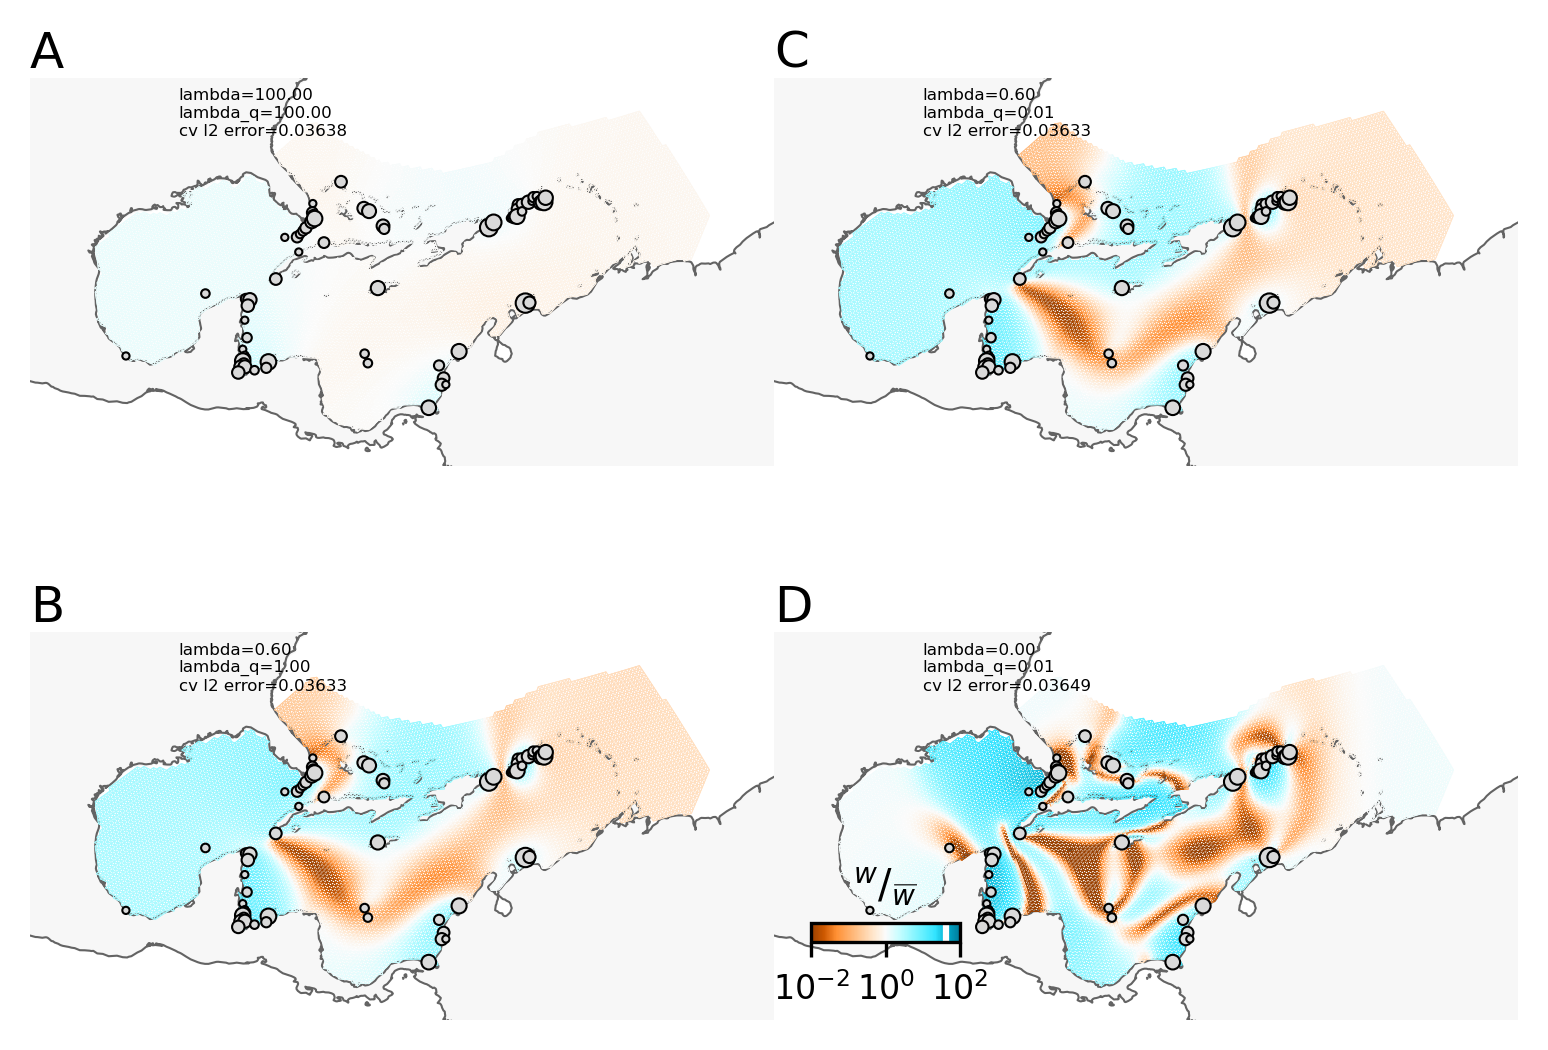

In [30]:
# figure params
projection = ccrs.AzimuthalEquidistant(central_longitude=-108.842926, central_latitude=66.037547)
title_loc = "left"
title_pad = "-10"
title_fontsize = 12
edge_width = .2
edge_alpha = 1
edge_zorder = 3
obs_node_size = 3
obs_node_linewidth = .4
cbar_font_size = 8
cbar_ticklabelsize = 8
cbar_orientation = "horizontal"

# figure setup
fig = plt.figure(dpi=300)
spec = gridspec.GridSpec(ncols=2, nrows=2, figure=fig, wspace=0.0, hspace=0.0)

# axis 00 
ax_00 = fig.add_subplot(spec[0, 0], projection=projection)
ax_00.set_title("A", loc=title_loc, pad=title_pad, fontdict={"fontsize": title_fontsize})
sp_graph.fit(lamb=lamb_grid[0], lamb_q=lamb_q_grid[0])
v = Viz(ax_00, sp_graph, projection=projection, edge_width=edge_width, 
        edge_alpha=1, edge_zorder=100, sample_pt_size=20, 
        obs_node_size=obs_node_size, sample_pt_color="black", 
        cbar_font_size=10)
v.draw_map(longlat=False)
v.draw_edges(use_weights=True)
v.draw_obs_nodes(use_ids=False) 
ax_00.text(.2, .85, "lambda={:.2f}\nlambda_q={:.2f}\ncv l2 error={:.5f}".format(lamb_grid[0], lamb_q_grid[0], mean_cv_err[0, 0]), 
           fontdict={"fontsize": 4}, transform = ax_00.transAxes)

# axis 10
ax_10 = fig.add_subplot(spec[1, 0], projection=projection)
ax_10.set_title("B", loc=title_loc, pad=title_pad, fontdict={"fontsize": title_fontsize})
sp_graph.fit(lamb=lamb_cv, lamb_q=lamb_q_cv)
v = Viz(ax_10, sp_graph, projection=projection, edge_width=edge_width, 
        edge_alpha=1, edge_zorder=100, sample_pt_size=20,
        obs_node_size=obs_node_size, sample_pt_color="black", 
        cbar_font_size=10)
v.draw_map(longlat=False)
v.draw_edges(use_weights=True)
v.draw_obs_nodes(use_ids=False) 
ax_10.text(.2, .85, "lambda={:.2f}\nlambda_q={:.2f}\ncv l2 error={:.5f}".format(lamb_cv, lamb_q_cv, mean_cv_err[np.where(lamb_q_cv==lamb_q_grid)[0][0], np.where(lamb_cv==lamb_grid)[0][0]]), 
           fontdict={"fontsize": 4}, transform = ax_10.transAxes)

# axis 01
ax_01 = fig.add_subplot(spec[0, 1], projection=projection)
ax_01.set_title("C", loc=title_loc, pad=title_pad, fontdict={"fontsize": title_fontsize})
sp_graph.fit(lamb=lamb_cv, lamb_q=0.01*lamb_q_cv)
v = Viz(ax_01, sp_graph, projection=projection, edge_width=edge_width, 
        edge_alpha=1, edge_zorder=100, sample_pt_size=20, 
        obs_node_size=obs_node_size, sample_pt_color="black", 
        cbar_font_size=10)
v.draw_map(longlat=False)
v.draw_edges(use_weights=True)
v.draw_obs_nodes(use_ids=False) 
ax_01.text(.2, .85, "lambda={:.2f}\nlambda_q={:.2f}\ncv l2 error={:.5f}".format(lamb_cv, 0.01*lamb_q_cv, mean_cv_err[np.where(0.01*lamb_q_cv==lamb_q_grid)[0][0], np.where(lamb_cv==lamb_grid)[0][0]]), 
           fontdict={"fontsize": 4}, transform = ax_01.transAxes)

# axis 11
ax_11 = fig.add_subplot(spec[1, 1], projection=projection)
ax_11.set_title("D", loc=title_loc, pad=title_pad, fontdict={"fontsize": title_fontsize})
sp_graph.fit(lamb=lamb_grid[-2], lamb_q=lamb_q_grid[-1])
v = Viz(ax_11, sp_graph, projection=projection, edge_width=edge_width, 
        edge_alpha=1, edge_zorder=100, sample_pt_size=20, 
        obs_node_size=obs_node_size, sample_pt_color="black", 
        cbar_font_size=10)
v.draw_map(longlat=False)
v.draw_edges(use_weights=True)
v.draw_obs_nodes(use_ids=False)
v.cbar_font_size = cbar_font_size
v.cbar_orientation = cbar_orientation
v.cbar_ticklabelsize = cbar_ticklabelsize
v.draw_edge_colorbar()
ax_11.text(.2, .85, "lambda={:.2f}\nlambda_q={:.2f}\ncv l2 error={:.5f}".format(lamb_grid[-2], lamb_q_grid[-1], mean_cv_err[-1, -2]), 
           fontdict={"fontsize": 4}, transform = ax_11.transAxes)

In [31]:
# lamb & lamb_q CV values
lamb_q_cv = lamb_q_grid[np.where(mean_cv_err == np.min(mean_cv_err))[0][0]]
lamb_cv = lamb_grid[np.where(mean_cv_err == np.min(mean_cv_err))[1][0]]
print(lamb_cv, lamb_q_cv)

0.5994842503189408 1.0


In [32]:
%%time
sp_graph.fit(lamb = lamb_cv, lamb_q = lamb_q_cv, optimize_q = 'n-dim')

CPU times: user 21min 51s, sys: 4min 3s, total: 25min 55s
Wall time: 3min 19s


In [33]:
projection = ccrs.PlateCarree(central_longitude=-77.32)#, central_latitude=-16.6076543)

findfont: Font family 'Arial' not found.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


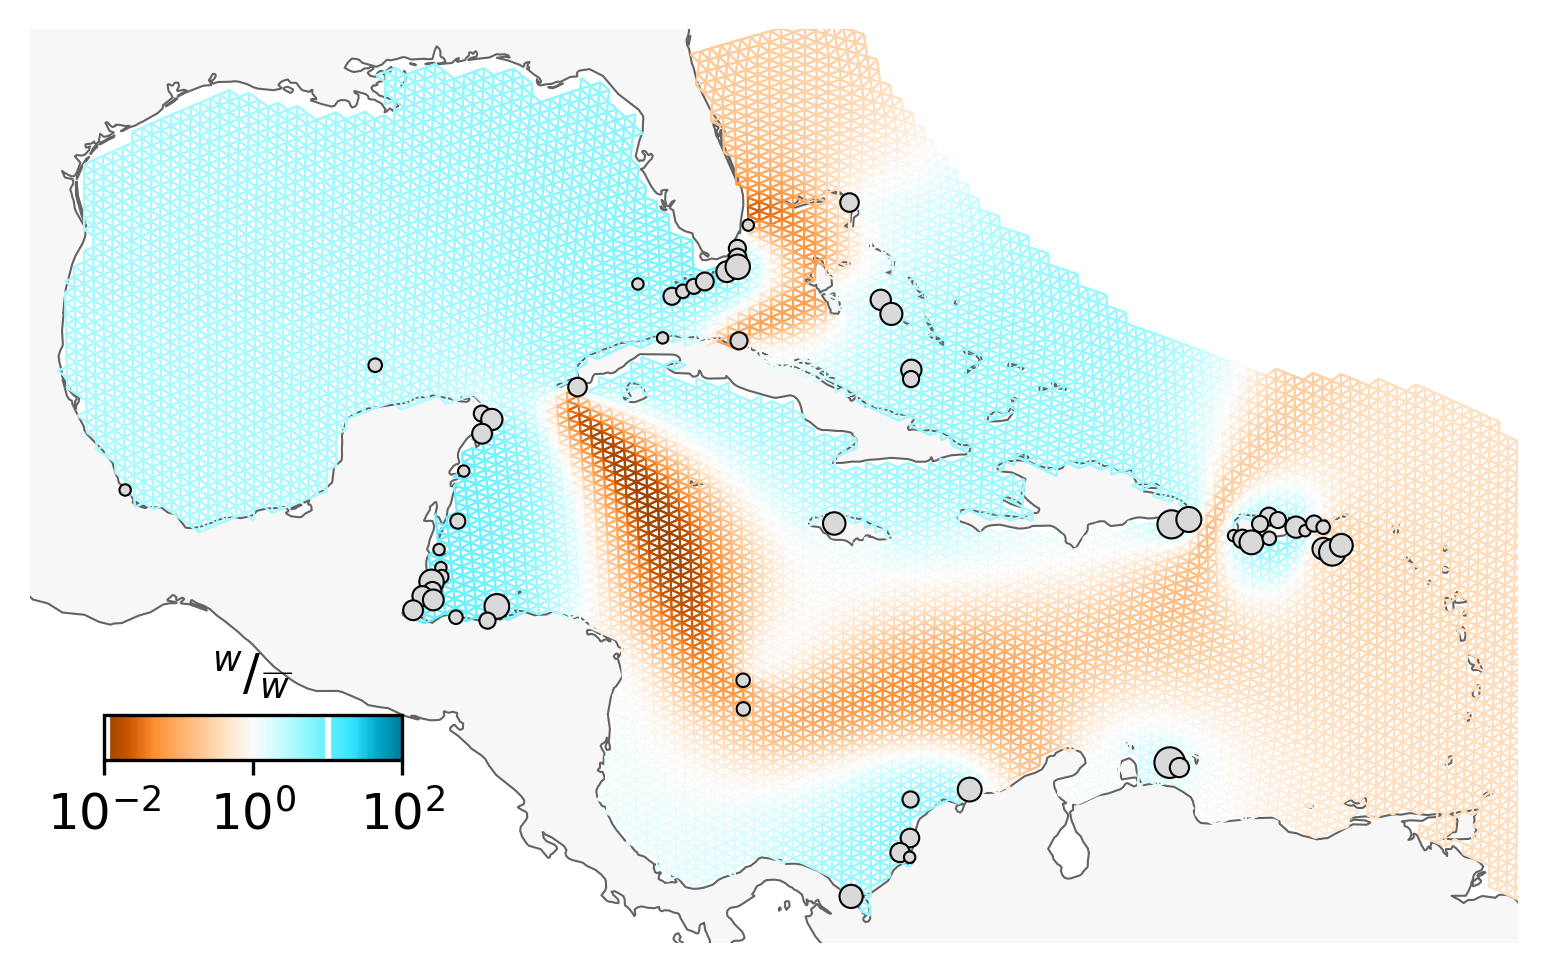

In [34]:
fig = plt.figure(dpi=300)
ax = fig.add_subplot(1, 1, 1, projection=projection)  
ax.set_extent([-98.6, -59.89, 7.42, 29.9])
v = Viz(ax, sp_graph, projection=projection, edge_width=.5, 
        edge_alpha=1, edge_zorder=100, sample_pt_size=20, 
        obs_node_size=7.5, sample_pt_color="black", 
        cbar_font_size=10)
v.draw_map()
v.draw_edges(use_weights=True)
v.draw_obs_nodes(use_ids=False) 
v.draw_edge_colorbar()
fig.savefig("../figures/feems.pdf", dpi = 300)

Text(0.5, 1.0, '$\\tt{FEEMS}$ fit with estimated node-specific variances')

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

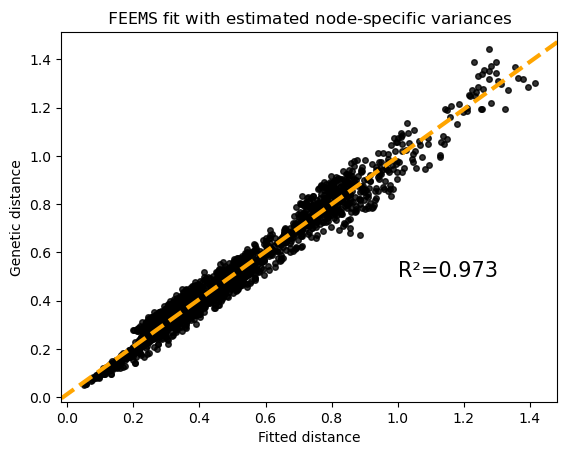

In [35]:
# creating an obj 
obj = Objective(sp_graph); obj.inv(); obj.grad(reg=False)
# computing distances matrice for fit (expected) vs empirical (observed) 
fit_cov, _, emp_cov = comp_mats(obj)
# subsetting matrices to arrays 
fit_dist = cov_to_dist(fit_cov)[np.tril_indices(sp_graph.n_observed_nodes, k=-1)]
emp_dist = cov_to_dist(emp_cov)[np.tril_indices(sp_graph.n_observed_nodes, k=-1)]

# fitting a linear model to the observed distances
X = sm.add_constant(fit_dist)
mod = sm.OLS(emp_dist, X)
res = mod.fit()
muhat, betahat = res.params

plt.figure(dpi=100)
plt.plot(fit_dist, emp_dist, 'o', color='k', alpha=0.8, markersize=4)
plt.axline((0.5,0.5*betahat+muhat), slope=betahat, color='orange', ls='--', lw=3)
plt.text(1, 0.5, "R²={:.3f}".format(res.rsquared), fontsize=15)
plt.xlabel('Fitted distance'); plt.ylabel('Genetic distance')
plt.title(r"$\tt{FEEMS}$ fit with estimated node-specific variances")

In [36]:
# choose a specified level 
outliers_df = sp_graph.extract_outliers(0.01)

Using a top fraction of 0.01: 
  Putative recipient demes: [6655, 6779, 7008, 6721, 6957, 3580, 6781]


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

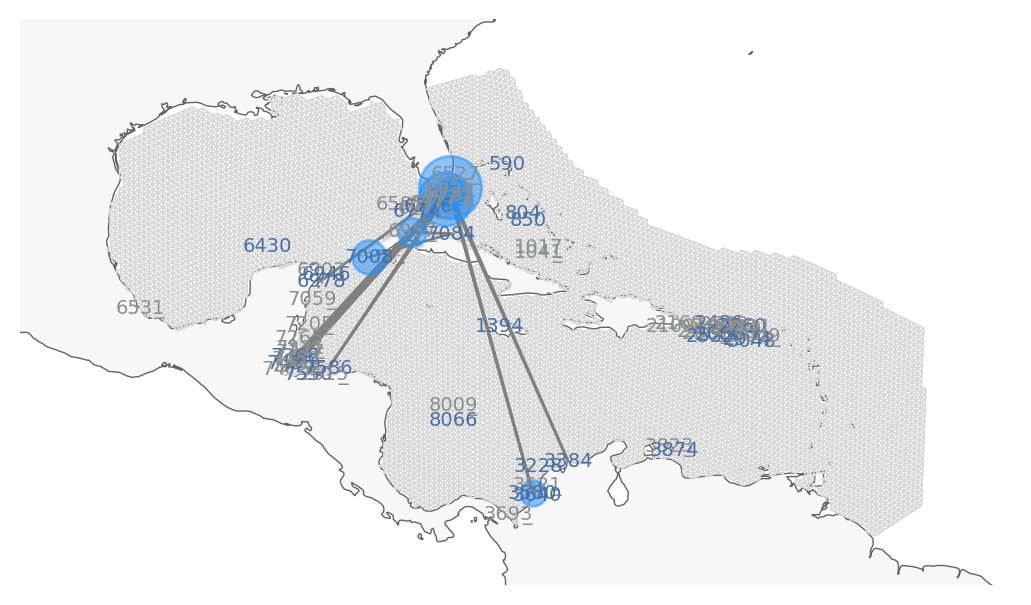

In [37]:
# visualizing the outlier demes on the map
fig = plt.figure(dpi=200)
ax = fig.add_subplot(1, 1, 1, projection=projection)  
v = Viz(ax, sp_graph, projection=projection, edge_width=.5, 
        edge_alpha=1, edge_zorder=100, sample_pt_size=20, 
        obs_node_size=7.5, sample_pt_color="black", 
        cbar_font_size=10)
v.draw_map(); v.draw_edges(use_weights=False)
# ~NEW~ function
v.draw_outliers(outliers_df)
# using deme IDs since all results will be represented with these numbers
v.draw_obs_nodes(use_ids=True)